### Formulation

The propagator is
$$
\begin{gather*}
    K(q_f, q_i, t)=\langle q_f|e^{-i\hat{H}t/\hbar}|q_i\rangle=\int\mathcal{D}q~e^{iS[q]/\hbar}\\
    S[q]=\int dt~\bigg(\frac{1}{2}m\dot{q}^2-V(q)\bigg)
\end{gather*}
$$
Using the Wick rotation, $t=-i\tau$,
$$
\begin{gather*}
    \dot{q}^2=\bigg(\frac{dq}{dt}\bigg)^2=\bigg(\frac{dq}{d\tau}\frac{1}{-i}\bigg)^2=-\bigg(\frac{dq}{d\tau}\bigg)^2\\
    \frac{i}{\hbar}S[q]=\frac{i}{\hbar}\int -id\tau~\bigg(-\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2-V(q)\bigg)=\frac{-1}{\hbar}\int d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q)\bigg)=\frac{-1}{\hbar}S_E[q]\\
    \therefore K_E(q_f, q_i, \tau)=\langle q_f|e^{-\hat{H}\tau/\hbar}|q_i\rangle=\int\mathcal{D}q~e^{-S_E[q]/\hbar}
\end{gather*}
$$
with the Euclidean action $S_E$,
$$
\begin{gather*}
    S_E[q]=\int_0^\tau d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q(\tau))\bigg)
\end{gather*}
$$
This Formulation implies connection to statistical physics. The partition function is
$$
\begin{gather*}
    Z=\mathrm{tr}(e^{-\beta\hat{H}})=\int dq~\langle q|e^{-\beta\hat{H}}|q\rangle
\end{gather*}
$$
If we replace $\tau=\hbar\beta$,
$$
\begin{gather*}
    Z=\int dq~\langle q|e^{-\beta\hat{H}}|q\rangle=\int dq~K_E(q, q, \hbar\beta)=\int\mathcal{D}q~e^{-S_E[q]/\hbar},\quad q(0)=q(\hbar\beta)
\end{gather*}
$$
$S_E$ can be discretized as
$$
\begin{gather*}
    S_E[q]=\int_0^{\hbar\beta} d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q(\tau))\bigg)\approx h\sum_i\bigg(\frac{1}{2}m\bigg(\frac{q_{i+1}-q_i}{h}\bigg)^2+V(q_i)\bigg)
\end{gather*}
$$
with $\tau_i=ih$ and $q_i=q(\tau_i)$. $h$ is the imaginary time step. After local update at certain site $j$, $q_j\to q_j+\eta$, the differecne of Euclidean action is
$$
\begin{align*}
    \Delta S_E/h=(S_E[q+\eta]-S_E[q])/h&=\frac{m}{2}\bigg(\bigg(\frac{q_{j+1}-(q_j+\eta)}{h}\bigg)^2 - \bigg(\frac{q_{j+1}-q_j}{h}\bigg)^2 + \bigg(\frac{(q_j+\eta) - q_{j-1}}{h}\bigg)^2 - \bigg(\frac{q_j - q_{j-1}}{h}\bigg)^2\bigg)+V(q_j+\eta)-V(q_j)\\
    &=\frac{m}{2h^2}\bigg((q_{j+1}-q_j-\eta)^2 - (q_{j+1}-q_j)^2 + (q_j+\eta - q_{j-1})^2 - (q_j - q_{j-1})^2\bigg)+V(q_j+\eta)-V(q_j)\\
    &=\frac{m}{2h^2}\bigg(q_{j+1}^2+q_j^2+\eta^2-2q_{j+1}q_j-2q_{j+1}\eta+2q_j\eta-q_{j+1}^2-q_j^2+2q_{j+1}q_j\\
    &\qquad\quad+ q_j^2+q_{j-1}^2+\eta^2+2q_j\eta-2q_jq_{j-1}-2q_{j-1}\eta - q_j^2-q_{j-1}^2+2q_jq_{j-1}\bigg)+V(q_j+\eta)-V(q_j)\\
    \Delta S_E&=\frac{m}{h}(\eta^2-\eta(q_{j+1}-2q_j+q_{j-1}))+h(V(q_j+\eta)-V(q_j))\\
\end{align*}
$$


In [1]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from tqdm import tqdm

In [130]:
class pathIntegral_particle:
    def __init__(self, N, dt, delta, V):
        self.N = N
        self.dt = dt
        self.delta = delta
        self.V = V

        #self.q = nr.randn(N)
        self.q = nr.uniform(-5, 5, N)
        self.beta = self.N*self.dt # inverse temperature


    def S_E(self):
        # Euclidean action or Energy of system

        v = np.roll(self.q, -1) - self.q
        S = np.sum(0.5*v*v/self.dt + self.V(self.q)*self.dt)

        return S
    

    def Metropolis(self, j):
        # Metropolis altorithm

        #j = nr.randint(self.N) # Random index for update
        eta = nr.uniform(-self.delta, self.delta) # Random displacement at q[j]

        # Difference of S_E after local update
        jp = (j+1)%self.N
        jm = (j-1)%self.N
        dS = 1/self.dt*(eta*eta - eta*(self.q[jp] - 2*self.q[j] + self.q[jm])) + self.dt*(self.V(self.q[j]+eta) - self.V(self.q[j]))

        if (dS <= 0) or (nr.rand() < np.exp(-dS)):
            # Acceptance condition
            self.q[j] += eta

            return 1 
        
        return 0
    

    def segmentReflect(self):
        i, k = sorted(nr.choice(self.N, size=2, replace=False)) # reflection interval [i,k]
        im = (i-1)%self.N
        kp = k%self.N

        #dS = (0.5*(-self.q[i] - self.q[im])**2/self.dt) + (0.5*(self.q[kp] + self.q[k-1])**2/self.dt) -\
        #     (0.5*(self.q[i] - self.q[im])**2/self.dt) - (0.5*(self.q[kp] - self.q[k-1])**2/self.dt)
        dS = 2/self.dt*(self.q[i]*self.q[im] + self.q[kp]*self.q[kp-1])
             
        
        if (dS <= 0) or (nr.rand() < np.exp(-dS)):
            # Acceptance condition
            self.q[i:k] *= -1

            return 1 
        
        return 0        


    def MonteCarlo(self, eq_sweeps=10**5, MC_sweeps=5*10**5, p_reflect=0.0):
        metropolisAcceptance = 0 # number of acceptance event
        reflectionAcceptance = 0
        reflectTrials = 0
        ensemble = []

        # Equilibriate steps
        print("Equilibriate steps")
        for _ in tqdm(range(eq_sweeps)):
            for j in range(self.N):
                self.Metropolis(j)

        # Monte Carlo steps
        print("Monte Carlo steps")
        for i in tqdm(range(MC_sweeps)):
            for j in range(self.N):
                metropolisAcceptance += self.Metropolis(j)

            if nr.rand() < p_reflect:
                reflectTrials += 1
                reflectionAcceptance += self.segmentReflect()

            if i%100 == 0:
                # 1 ensemble sampling per 100 sweep
                ensemble.append(np.copy(self.q))

        acceptanceRate = metropolisAcceptance/(MC_sweeps*self.N)
        

        q_ensemble = np.array(ensemble)

        return acceptanceRate, [reflectionAcceptance, reflectTrials], q_ensemble
    

def G(q_ensemble, tau):
    # Correlation function
    C = np.zeros_like(tau, dtype=float)

    for i, t in enumerate(tau):
        q_tau = np.roll(q_ensemble, -t, axis=1)
        C[i] = np.mean(q_ensemble*q_tau)

    return C

### 1. Harmonic oscillator

The quantum harmonic oscillator is
$$
\begin{gather*}
    V(q)=\frac{1}{2}m\omega^2q^2
\end{gather*}
$$
The ground state wave function and probability density are
$$
\begin{gather*}
    \psi_0(q)=\bigg(\frac{m\omega}{\pi\hbar}\bigg)^{1/4}\exp\bigg(-\frac{m\omega q^2}{2\hbar}\bigg),\quad|\psi_0(q)|^2=\bigg(\frac{m\omega}{\pi\hbar}\bigg)^{1/2}\exp\bigg(-\frac{m\omega q^2}{\hbar}\bigg)
\end{gather*}
$$
For convenience, we choosed the dimensionless unit $m=\hbar=1$. Then,
$$
\begin{gather*}
    V(q)=\frac{1}{2}\omega^2q^2,\quad |\psi_0(q)|^2=\bigg(\frac{\omega}{\pi}\bigg)^{1/2}e^{-\omega q^2}
\end{gather*}
$$
The correlation function $G(\tau)$ is given by
$$
\begin{align*}
    G(\tau)=\langle q(\tau)q(0)\rangle
\end{align*}
$$
In the operator formalism, $\hat{q}(\tau)=e^{H\tau}\hat{q}(0)e^{-H\tau}=e^{H\tau}\hat{q}e^{-H\tau},~(\hat{q}(0)=\hat{q})$. Therefore,
$$
\begin{align*}
    G(\tau)=\langle q(\tau)q(0)\rangle=\langle 0|e^{H\tau}\hat{q}e^{-H\tau}\hat{q}|0\rangle
\end{align*}
$$
Here, we can use the orthornomal relation and energy spectrum of quantum harmonic oscillator
$$
\begin{align*}
    &I=\sum_n|n\rangle\langle n|,~E_n=\omega\bigg(n+\frac{1}{2}\bigg)\\
    G(\tau)&=\langle 0|e^{H\tau}\hat{q}e^{-H\tau}\hat{q}|0\rangle=\sum_n\langle 0|e^{H\tau}\hat{q}|n\rangle\langle n|e^{-H\tau}\hat{q}|0\rangle\\
    &=\sum_n\langle 0|e^{E_0\tau}\hat{q}|n\rangle\langle n|e^{-E_n\tau}\hat{q}|0\rangle=\sum_ne^{(E_0-E_n)\tau}|\langle n|\hat{q}|0\rangle|^2
\end{align*}
$$
Also, using the creation operator $\hat{a}^\dagger$ and annihilation operator $\hat{a}$,
$$
\begin{gather*}
    \hat{q}=\frac{1}{\sqrt{2\omega}}(\hat{a}+\hat{a}^\dagger)\\
    \langle n|\hat{q}|0\rangle=\frac{1}{\sqrt{2\omega}}\langle n|(\hat{a}+\hat{a}^\dagger)|0\rangle=\frac{1}{\sqrt{2\omega}}\delta_{n,1}\\
    G(\tau)=\frac{1}{2\omega}\sum_ne^{(E_0-E_n)\tau}\delta_{n,1}=\frac{1}{2\omega} e^{(E_0-E_1)\tau}=\frac{1}{2\omega} e^{-\omega\tau}
\end{gather*}
$$
Form this $G(\tau)$, we can extract $\omega$. 
$$
\begin{gather*}
    \frac{G(\tau)}{G(\tau+h)}=\frac{e^{-\omega\tau}}{e^{-\omega(\tau+h)}}=e^{\omega h}\\
    \omega_\text{eff}=\frac{1}{h}\ln\frac{G(\tau)}{G(\tau+h)}
\end{gather*}
$$


In [6]:
class HarmonicOscillator:
    def __init__(self, w):
        self.w = w

    
    def __call__(self, q):
        return 0.5*(self.w**2)*(q**2)


def P0(q, w):
    # |\psi_0(q)|^2
    return np.sqrt(w/np.pi)*np.exp(-w*q*q)

In [ ]:
w = 2
N = 100
h = 0.1
delta = 0.5

sim1 = pathIntegral_particle(N, h, delta, HarmonicOscillator(w))
acceptance_rate, reflectionAcceptanceRate, q_ensemble = sim1.MonteCarlo()
print(acceptance_rate)

Equilibriate steps


100%|██████████| 100000/100000 [01:16<00:00, 1313.58it/s]


Monte Carlo steps


100%|██████████| 500000/500000 [07:40<00:00, 1085.07it/s]

0.59193628


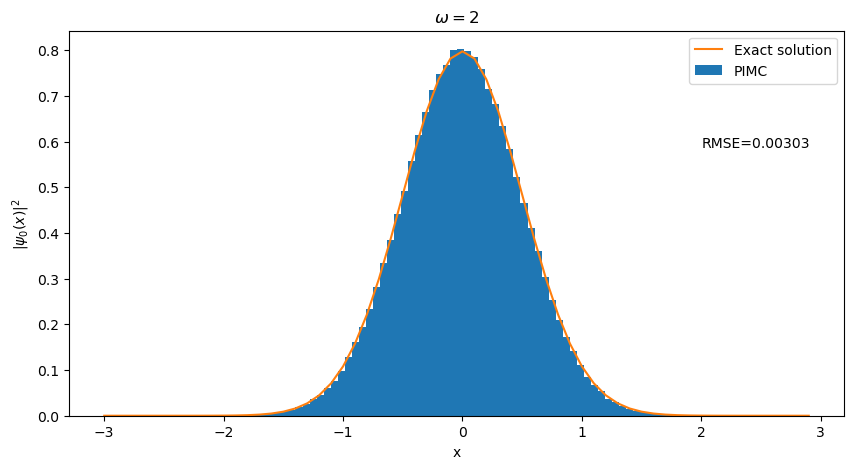

<q^2>
Exact value=0.25
Numerical value=0.24747368371203685
0.0011202459022468829


In [103]:
fig = plt.figure(figsize=(10, 5))
'''
plt.subplot(121)
plt.plot(sim1.q, range(sim1.N))
plt.xlabel('q')
plt.ylabel('$\\tau$')

plt.subplot(122)
'''
q_list = np.arange(-3, 3, 0.1)
p = P0(q_list, w)
hist, edges = np.histogram(q_ensemble.flatten(), bins=80, density=True)
centers = 0.5 * (edges[:-1] + edges[1:]) # centers of each bins
dx = edges[1] - edges[0]
plt.bar(centers, hist, width=dx, label="PIMC")
plt.plot(q_list, p, color='C1', label='Exact solution')
plt.xlabel('x')
plt.ylabel('$|\\psi_0(x)|^2$')
plt.title("$\\omega=$"+f"{w}")
plt.legend()

P_exact = P0(centers, w)
rmse = np.sqrt(np.mean((hist - P_exact)**2))
plt.text(2, np.max(P_exact)*2/np.e, f"RMSE={rmse:.5f}")

plt.show()

O = np.mean(q_ensemble**2, axis=1) # Observable
mean = np.mean(O)
var = np.var(O, ddof=1)
error = np.sqrt(var/len(O))

print("<q^2>")
print(f"Exact value={1/(2*w)}")
print(f"Numerical value={mean}")
print(error)

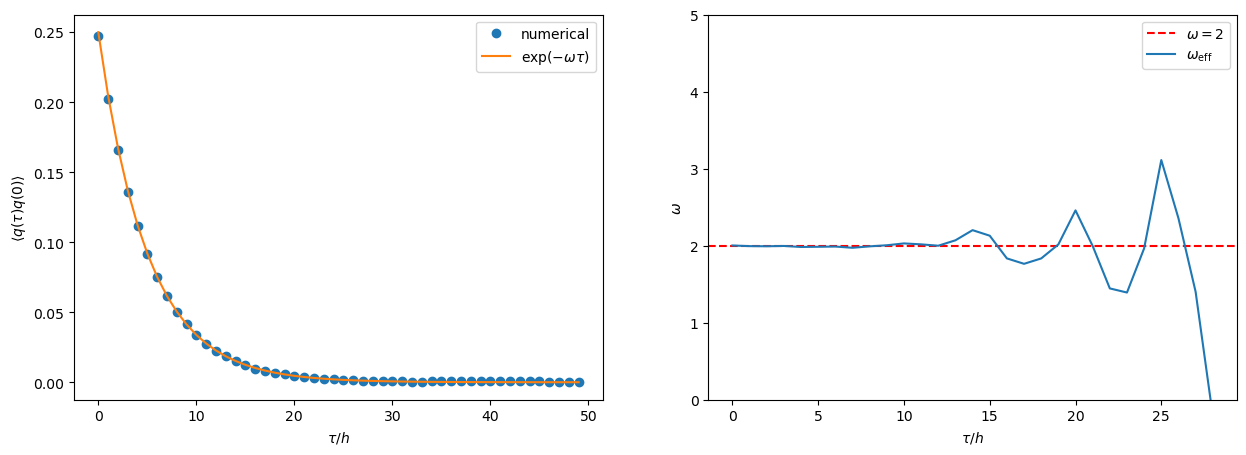

In [104]:
tau = np.arange(0, sim1.N//2)
C = G(q_ensemble, tau)
C_exact = 1/(2*w)*np.exp(-w*tau*sim1.dt)

w_eff = np.log(C[:29]/C[1:30])/sim1.dt

fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.plot(tau, C, 'o', label='numerical')
plt.plot(tau, C_exact, label='$\\exp(-\\omega\\tau)$')
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\langle q(\\tau)q(0)\\rangle$')
plt.legend()

plt.subplot(122)
plt.axhline(w, color='r', linestyle='--', label="$\\omega=$"+f"{w}")
plt.plot(w_eff, label="$\\omega_\\text{eff}$")
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\omega$')
plt.ylim(0, 5)
plt.legend()

plt.show()

In [105]:
def autocorr(O):
    O = np.asarray(O)
    O = O - np.mean(O)

    corr = np.correlate(O, O, mode='full')
    corr = corr[len(O)-1:]

    corr /= np.arange(len(O), 0, -1)

    return corr / corr[0]

O = np.mean(q_ensemble**2, axis=1)

rho = autocorr(O)

neg = np.where(rho < 0)[0]

if len(neg) > 0:
    cut = neg[0]
else:
    cut = len(rho)

tau_int = 0.5 + np.sum(rho[1:cut])
print(tau_int)


0.6162571018521015


### 2. Anharmonic oscillator

Next case is the Anharmonic oscillator defined as
$$
\begin{gather*}
    V(q)=\mu q^2 + \lambda q^4
\end{gather*}
$$
This potential has global minimum at $q=\pm \sqrt{\frac{-\mu}{2\lambda}}$ for $\mu<0$. Unlike to harmonic oscillator, this case does not have analytic solution. Therefore, we need another numerical simulation using FDM. The Shrodinger eqution is given as (dimensionless unit with $m=\hbar=1$)
$$
\begin{gather*}
    -\frac{1}{2}\frac{\partial^2}{dq^2}\psi_n(q) + V(q)\psi_n(q)=E_n\psi_n(q)
\end{gather*}
$$
Using $q\to q_i$, $V_i=V(q_i)$ and $\psi_i=\psi_n(q_i)$ (we ommited $n$ for convenience),
$$
\begin{align*}
    E\psi_i&=-\frac{1}{2}\frac{\psi_{i+1}+\psi_{i-1}-2\psi_i}{\Delta x^2} + V_i\psi_i\\
    &=-\frac{1}{2\Delta x^2}\psi_{i-1}-\frac{1}{2\Delta x^2}\psi_{i+1}+\bigg(\frac{1}{\Delta x^2} + V_i\bigg)\psi_i\\
    &=L_i\psi_{i-1} + R_i\psi_{i+1} + D_i\psi_i
\end{align*}
$$
The boundary condition is $\psi_n(q\to\pm\infty)=0$. However, in the numerical simulation, system is alway finite so we should use $\psi_n(\pm L)=0$, or in the discretized formulation, $\psi_0=\psi_N=0$ with the system size $2L$.

In [106]:
class AnharmonicOscillator:
    def __init__(self, mu, l):
        self.mu = mu # coupling with q^2
        self.l = l # coupling with q^4

    
    def __call__(self, q):
        return self.mu*q**2 + self.l*q**4

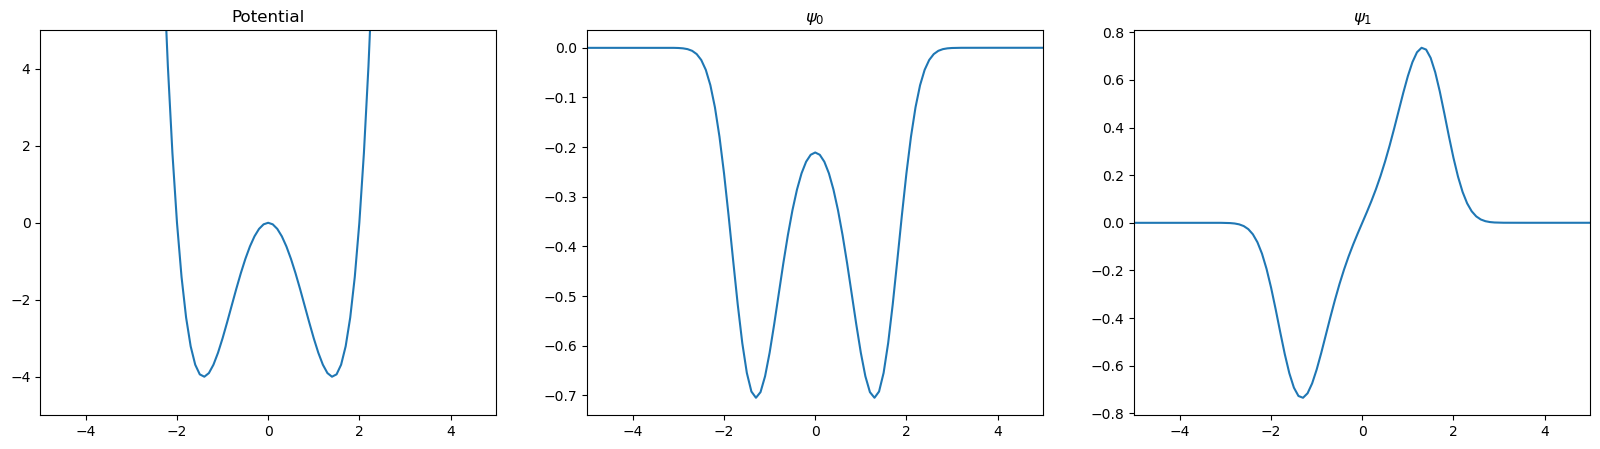

a=1.4142135623730951
E0=-2.202903785728802
E1=-2.107586413744459


In [107]:
# FDM for double well
L = 30
dx = 0.1
x = np.linspace(-L, L, int(2*L/dx)+1)

mu = -4
l = 1
a = np.sqrt(-mu/(2*l))
V = AnharmonicOscillator(mu, l)(x)

Di = 1/dx**2 + V
Li = -1/(2*dx**2)*np.ones_like(x)
Ri = -1/(2*dx**2)*np.ones_like(x)

H = np.diag(Di) + np.diag(Li[1:], -1) + np.diag(Ri[:-1], 1) 

E, psi = np.linalg.eigh(H)
order = np.argsort(E)
E = E[order]
psi = psi[:, order]
norms = np.sum(np.abs(psi)**2, axis=0)*dx
psi /= np.sqrt(norms)


E0 = E[0]
psi_0 = psi[:, 0]
p0 = np.abs(psi_0)**2

E1 = E[1]
psi_1 = psi[:, 1]
p1 = np.abs(psi_1)**2

psi_plus = (psi_0 + psi_1)/np.sqrt(2)
psi_minus = (psi_0 - psi_1)/np.sqrt(2)

fig = plt.figure(figsize=(20, 5))

plt.subplot(131)
plt.plot(x, V)
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.title('Potential')

plt.subplot(132)
plt.plot(x, psi_0)
#plt.plot(x, psi_plus**2, label=f'$\psi_+$')
plt.xlim((-5, 5))
#plt.ylim((-1, 1))
plt.title('$\psi_0$')

plt.subplot(133)
plt.plot(x, psi_1)
#plt.plot(x, psi_minus**2, label=f'$\psi_-$')
plt.xlim((-5, 5))
#plt.ylim((-1, 1))
plt.title('$\psi_1$')

plt.show()

print(f"a={a}")
print(f"E0={E0}")
print(f"E1={E1}")


In [131]:
N = 100
h = 0.1
delta = 2.0

sim2 = pathIntegral_particle(N, h, delta, AnharmonicOscillator(mu, l))
acceptance_rate, reflectionAcceptance, q_ensemble = sim2.MonteCarlo(p_reflect=0.5)
print(acceptance_rate)
print(reflectionAcceptance)

Equilibriate steps


100%|██████████| 100000/100000 [00:39<00:00, 2514.56it/s]


Monte Carlo steps


100%|██████████| 500000/500000 [03:55<00:00, 2119.31it/s]

0.17344
[316, 249425]


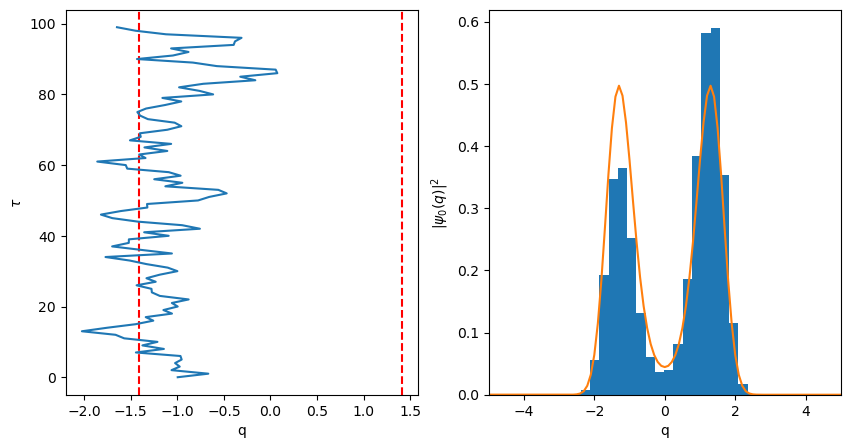

<q^2>
Exact value=1.6290408127638405
Numerical value=1.6648205849372986
0.0036184136263887725


In [135]:
#psi_plus = (psi_0+psi_1)/np.sqrt(2)
#p0 = psi_plus*psi_plus

fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.axvline(x=a, linestyle='--', color='r')
plt.axvline(x=-a, linestyle='--', color='r')
plt.plot(sim2.q, range(sim2.N))
plt.xlabel('q')
plt.ylabel('$\\tau$')

plt.subplot(122)
plt.hist(q_ensemble.flatten(), bins=20, density=True)
plt.plot(x, p0)
plt.xlim((-5, 5))
plt.xlabel('q')
plt.ylabel('$|\\psi_0(q)|^2$')

plt.show()

O = np.mean(q_ensemble**2, axis=1) # Observable
mean = np.mean(O)
var = np.var(O, ddof=1)
error = np.sqrt(var/len(O))

q2_FDM = integrate.simpson(x*x*p0, x=x) # FDM

print("<q^2>")
print(f"Exact value={q2_FDM}")
print(f"Numerical value={mean}")
print(error)

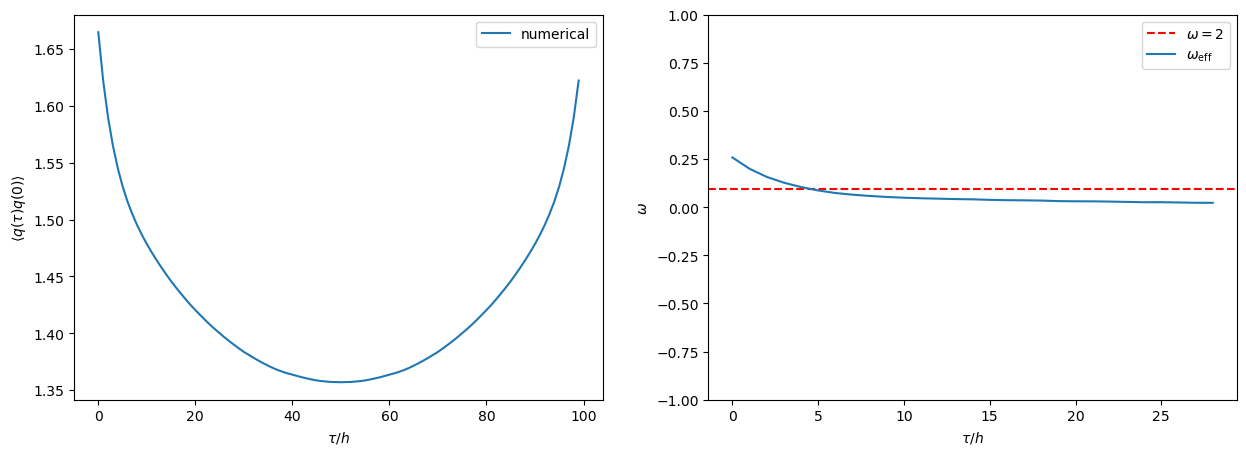

In [133]:
tau = np.arange(0, sim2.N)
C = G(q_ensemble, tau)

w_eff = np.log(C[:29]/C[1:30])/sim2.dt

fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.plot(tau, C, label='numerical')
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\langle q(\\tau)q(0)\\rangle$')
plt.legend()

plt.subplot(122)
plt.axhline((E1-E0), color='r', linestyle='--', label="$\\omega=$"+f"{w}")
plt.plot(w_eff, label="$\\omega_\\text{eff}$")
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\omega$')
plt.ylim(-1, 1)
plt.legend()

plt.show()

In [113]:
print(w_eff)
print(E1-E0)

[0.26079592 0.20390748 0.16258262 0.1336226  0.11363889 0.09761915
 0.08637718 0.07852692 0.07195237 0.06638589 0.06160747 0.05873748
 0.05686977 0.05534106 0.05144022 0.0479137  0.0466861  0.04670419
 0.04418389 0.04408489 0.04372749 0.04226503 0.04105236 0.0399196
 0.03893512 0.03848365 0.03748887 0.03332636 0.03122228]
0.09531737198434298


### 3. Manybody case

Worm algorithm: \
https://doi.org/10.1103/PhysRevLett.96.070601\
https://youtu.be/T_wvLg7z7gU?si=OQ-VJW_ZRcgopUBL

In [3]:
class pathIntegral_boson:
    def __init__(self, N, M, dt, delta, V):
        self.N = N # number of particles
        self.M = M # number of time slice
        self.dt = dt
        self.delta = delta
        self.V = V

        #self.q = nr.randn(N,M)
        self.q = nr.uniform(-5, 5, (N, M))

        self.next = np.zeros((N*M), dtype=int) # next bead indices
        self.prev = np.zeros((N*M), dtype=int) # previous bead indices

        for p in range(N):
            for t in range(M):
                idx = p*M + t

                tp = (t+1)%M
                tm = (t-1)%M

                self.next[idx] = p*M + tp
                self.prev[idx] = p*M + tm


        self.hasWorm = False
        self.head = 0 # head of worm
        self.tail = 0 # tail of worm
        '''
        self.next[self.head] = -1
        self.prev[self.tail] = -1
        '''

        self.beta = self.M*self.dt # inverse temperature


    def localMove(self):
        i = nr.randint(self.N*self.M)
        p, t = i // self.M, i % self.M
        
        i_next = self.next[i]
        i_prev = self.prev[i]

        eta = nr.uniform(-self.delta, self.delta)

        dS = self.dt*(self.V(self.q[p,t]+eta) - self.V(self.q[p,t])) # Potential contribution of dS

        # Below is the kinetic contribution of dS
        if (i_prev != -1) and (i_next != -1):
            q_next = self.q[i_next // self.M, i_next % self.M]
            q_prev = self.q[i_prev // self.M, i_prev % self.M]   
            dS += 1/self.dt*(eta*eta - eta*(q_next - 2*self.q[p,t] + q_prev))

        elif (i_prev == -1):
            # i is at the tail
            q_next = self.q[i_next // self.M, i_next % self.M] 
            dS += 0.5/self.dt*(eta*eta + 2*eta*(self.q[p,t] - q_next))

        elif (i_next == -1):
            # i is at the head
            q_prev = self.q[i_prev // self.M, i_prev % self.M]   
            dS += 0.5/self.dt*(eta*eta + 2*eta*(self.q[p,t] - q_prev))

        if (dS <= 0) or (nr.rand() < np.exp(-dS)):
            # acceptance condition
            self.q[p,t] += eta
            return 1
        
        return 0
    

    def linkS(self, i, j):
        if (i == -1) or (j == -1):
            return 0.0
        
        p_i, t_i = i//self.M, i%self.M
        p_j, t_j = j//self.M, j%self.M

        dx = self.q[p_j, t_j] - self.q[p_i, t_i]

        return 0.5*dx*dx/self.dt
    

    def exchangeMove(self):
        if self.N < 2 or self.hasWorm:
            return 0
        
        a, b = nr.choice(self.N, size=2, replace=False)

        # ia -> ja, ib -> jb
        ia = a*self.M + (self.M-1)
        ib = b*self.M + (self.M-1)

        ja = self.next[ia]
        jb = self.next[ib]

        S_old = self.linkS(ia, ja) + self.linkS(ib, jb)
        S_new = self.linkS(ia, jb) + self.linkS(ib, ja)

        dS = S_new - S_old

        if (dS <= 0) or (nr.rand() < np.exp(-dS)):
            # exchange
            self.next[ia] = jb
            self.next[ib] = ja

            self.prev[ja] = ib
            self.prev[jb] = ia

            return 1
        
        return 0
    

    def permutation(self):
        perm = np.zeros(self.N, dtype=int)

        for p in range(self.N):
            last = p*self.M + (self.M-1) # get the last t of particle p
            nxt = self.next[last] # next index of (p,last)

            if nxt == -1:
                raise ValueError("Worm is open. Permutation is not defined.")
            
            p_next = nxt//self.M # next particle of p
            t_next = nxt%self.M

            if t_next != 0:
                raise ValueError("Boundary link does not point to t=0.")
            
            perm[p] = p_next

        return perm


    def cycleLength(self):
        # Calculate the cycle lengths of permutation
        perm = self.permutation()

        visited = np.zeros(self.N, dtype=bool)
        lengths = []

        for p in range(self.N):
            if visited[p]:
                # the case of the current cycle is visited
                continue

            cur = p
            length = 0

            while not visited[cur]:
                visited[cur] = True
                length += 1
                cur = perm[cur]

            lengths.append(length)

        return lengths


    def MonteCarlo(self, eq_sweeps=10**5, MC_sweeps=5*10**5, p_global=0.0):
        local_acceptance = 0 # number of acceptance event
        exchange_acceptance = 0
        ensemble = []
        cycles = []
        max_cycles = []

        # Equilibriate steps
        print("Equilibriate steps")
        for _ in tqdm(range(eq_sweeps)):
            for _ in range(self.M*self.N):
                self.localMove()

        # Monte Carlo steps
        print("Monte Carlo steps")
        for i in tqdm(range(MC_sweeps)):
            for _ in range(self.M*self.N):
                local_acceptance += self.localMove()

            for _ in range(self.N):
                exchange_acceptance += self.exchangeMove()

            if i%100 == 0:
                # 1 ensemble sampling per 100 sweep
                ensemble.append(np.copy(self.q))
                
                cycle_lngth = self.cycleLength()
                cycles.append(cycle_lngth)
                max_cycles.append(max(cycle_lngth))

        local_acceptanceRate = local_acceptance/(MC_sweeps*self.M*self.N)
        exchange_acceptanceRate = exchange_acceptance/(MC_sweeps*self.N)

        q_ensemble = np.array(ensemble)

        return local_acceptanceRate, exchange_acceptanceRate, q_ensemble, max_cycles

In [4]:
w = 1
N = 4
M = 200
h = 0.1
delta = 0.5

sim3 = pathIntegral_boson(N, M, h, delta, HarmonicOscillator(w))
local_acceptance_rate, exchange_acceptance_rate, q_ensemble, max_cycles = sim3.MonteCarlo()
print(local_acceptance_rate, exchange_acceptance_rate)

Equilibriate steps


100%|██████████| 100000/100000 [16:40<00:00, 99.97it/s]


Monte Carlo steps


100%|██████████| 500000/500000 [1:32:34<00:00, 90.01it/s]

0.594429355 0.2792135


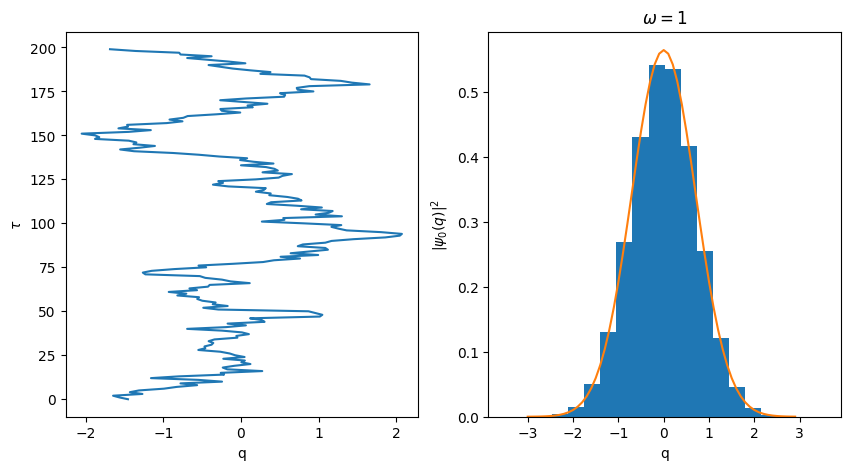

<q^2>
Exact value=0.5
Numerical value=0.5024747965326154


In [5]:
fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.plot(sim3.q[1,:], range(sim3.M))
plt.xlabel('q')
plt.ylabel('$\\tau$')

plt.subplot(122)
q_list = np.arange(-3, 3, 0.1)
p = P0(q_list, w)
plt.hist(q_ensemble.flatten(), bins=20, density=True)
plt.plot(q_list, p)
plt.xlabel('q')
plt.ylabel('$|\\psi_0(q)|^2$')
plt.title("$\\omega=$"+f"{w}")

plt.show()

q2_mean = np.mean(q_ensemble.flatten()**2)
print("<q^2>")
print(f"Exact value={1/(2*w)}")
print(f"Numerical value={q2_mean}")

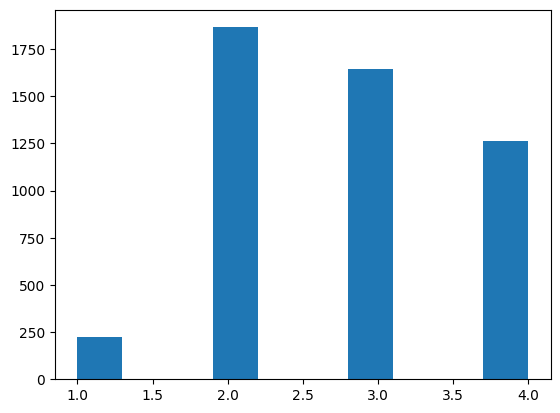

In [7]:
plt.hist(max_cycles)
plt.show()